# Capstone Project 2 - Predicting Daily Minimum Temperature (Melbourne, Australia)

**Dataset:** [Daily Minimum Temperatures in Melbourne](https://www.kaggle.com/datasets/paulbrabban/daily-minimum-temperatures-in-melbourne) : 3,650 daily minimum temperature readings (°C) recorded in Melbourne, Australia, from 1 Jan 1981 to 31 Dec 1990.

**Goal:** Build a model that predicts the next day's minimum temperature, using a chronological **80/20 train-test split** (required for time series, a random split would leak future information into training).


1. Load and clean the data, explore trend/seasonality
2. Engineer calendar + lag + rolling-window features
3. Chronological 80/20 split
4. Naive baselines (persistence, seasonal-naive)
5. Linear Regression, Random Forest, XGBoost (tuned with `TimeSeriesSplit`)
6. Classical time series: SARIMAX + Fourier terms, evaluated with proper walk-forward forecasting
7. Deep learning: LSTM and GRU sequence models
8. Compare RMSE / MAE / R² across all five model families, and inspect the overall best model




In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import tensorflow as tf
from tensorflow import keras

plt.rcParams['figure.figsize'] = (11, 4)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
DATA_PATH = "Temperature.csv" 


### Load & Inspect Data
---

In [6]:

raw = pd.read_csv(DATA_PATH, header=0, engine='python', on_bad_lines='skip')
raw.columns = ['Date', 'Temp']
raw['Date'] = pd.to_datetime(raw['Date'], errors='coerce')
raw['Temp'] = pd.to_numeric(raw['Temp'].astype(str).str.replace('?', '', regex=False), errors='coerce')
df = raw.dropna(subset=['Date', 'Temp']).sort_values('Date').reset_index(drop=True)

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nSummary stats:\n", df['Temp'].describe())
df.head()


Shape: (3650, 2)

Dtypes:
 Date    datetime64[us]
Temp           float64
dtype: object

Missing values:
 Date    0
Temp    0
dtype: int64

Summary stats:
 count    3650.000000
mean       11.177753
std         4.071837
min         0.000000
25%         8.300000
50%        11.000000
75%        14.000000
max        26.300000
Name: Temp, dtype: float64


,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [7]:
# The series should be one row per day for 10 years (1981-1990).

full_idx = pd.date_range(df['Date'].min(), df['Date'].max(), freq='D')
missing = full_idx.difference(df['Date'])
print(f"Calendar days in range: {len(full_idx)} | rows in file: {len(df)} | missing days: {len(missing)}")
print(missing.tolist())

df = df.set_index('Date').reindex(full_idx)
df.index.name = 'Date'
df['Temp'] = df['Temp'].interpolate()
df = df.reset_index()
assert df['Temp'].isna().sum() == 0


Calendar days in range: 3652 | rows in file: 3650 | missing days: 2
[Timestamp('1984-12-31 00:00:00'), Timestamp('1988-12-31 00:00:00')]


### Exploratory Data Analysis
---

Minimum temperature is a classic seasonal series: a strong yearly cycle (Melbourne winters/summers), day-to-day noise, and no obvious long-term trend over the 10 years.

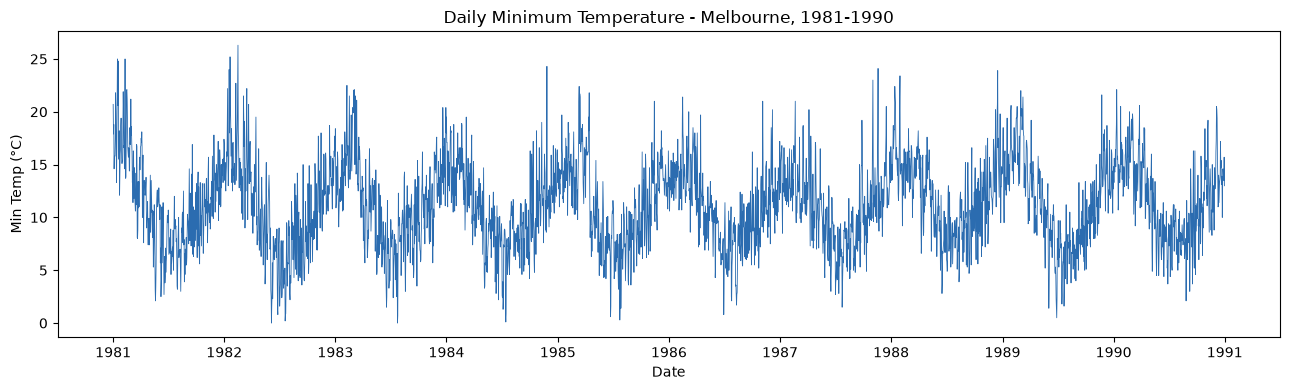

In [8]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['Date'], df['Temp'], linewidth=0.6, color='#2b6cb0')
ax.set_title("Daily Minimum Temperature - Melbourne, 1981-1990")
ax.set_xlabel("Date"); ax.set_ylabel("Min Temp (°C)")
plt.tight_layout(); plt.show()


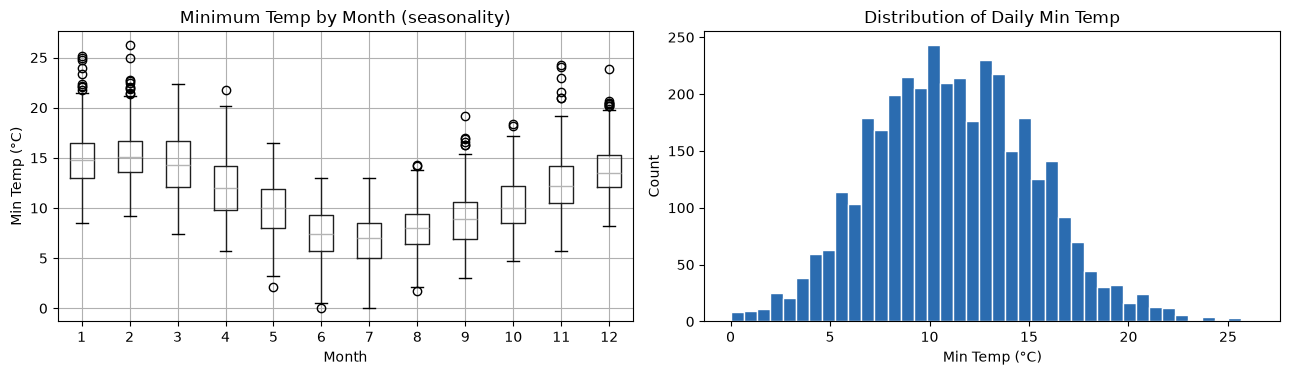

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['month'] = df['Date'].dt.month
df.boxplot(column='Temp', by='month', ax=axes[0])
axes[0].set_title("Minimum Temp by Month (seasonality)")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("Min Temp (°C)")
plt.suptitle("")

axes[1].hist(df['Temp'], bins=40, color='#2b6cb0', edgecolor='white')
axes[1].set_title("Distribution of Daily Min Temp")
axes[1].set_xlabel("Min Temp (°C)"); axes[1].set_ylabel("Count")

plt.tight_layout(); plt.show()


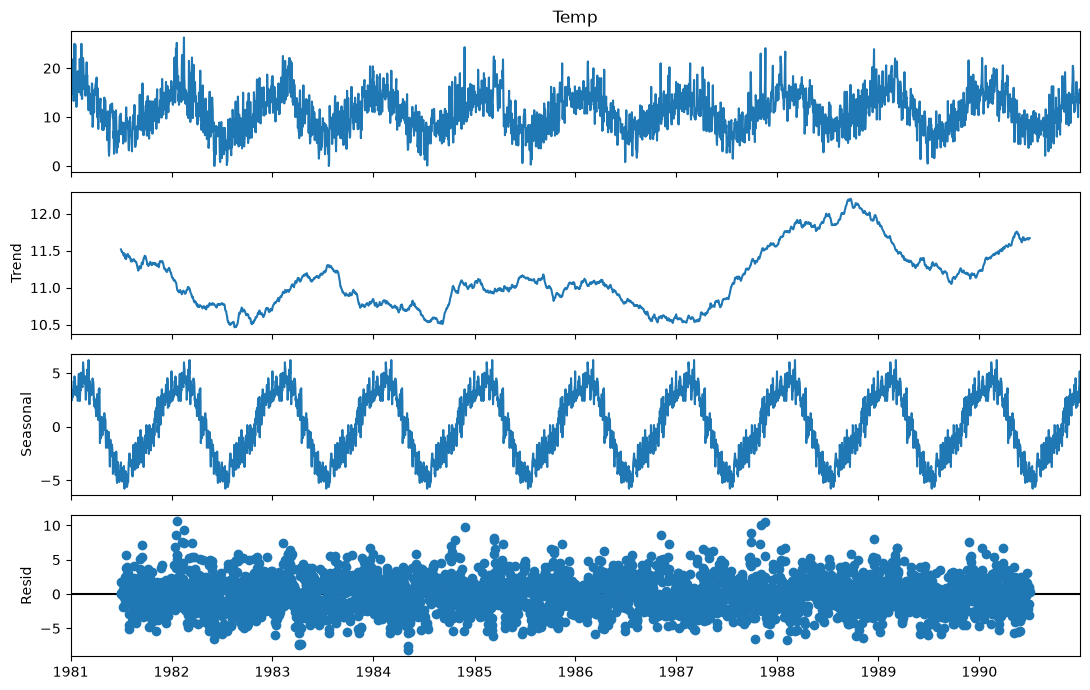

In [10]:
# Seasonal decomposition confirms an annual cycle with roughly stable amplitude
# and no strong multi-year trend.
decomp = seasonal_decompose(df.set_index('Date')['Temp'], model='additive', period=365)
fig = decomp.plot()
fig.set_size_inches(11, 7)
plt.tight_layout(); plt.show()


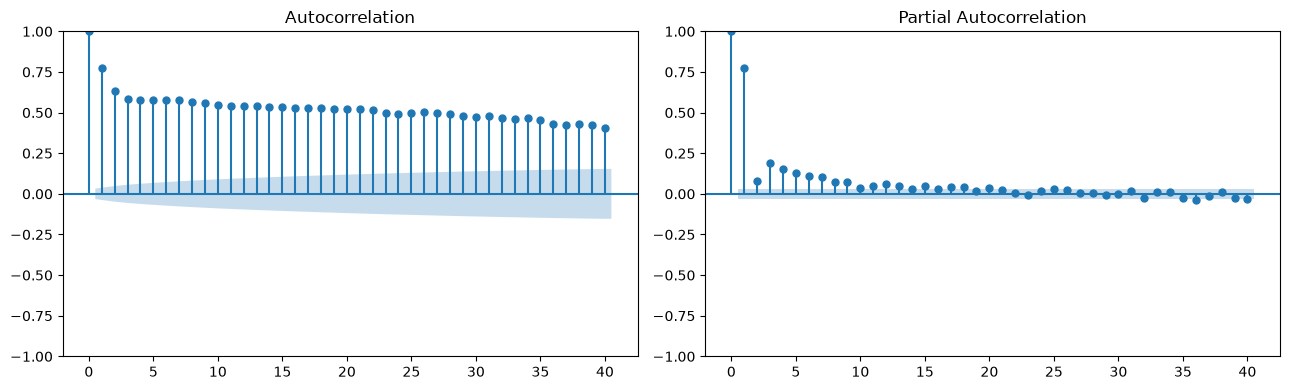

In [11]:
# ACF/PACF on the first differences guide which lags are worth engineering as features.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(df['Temp'], lags=40, ax=axes[0])
plot_pacf(df['Temp'], lags=40, ax=axes[1])
plt.tight_layout(); plt.show()


### Feature Engineering
---




In [12]:
d = df.copy()
d['doy'] = d['Date'].dt.dayofyear
d['doy_sin'] = np.sin(2 * np.pi * d['doy'] / 365.25)
d['doy_cos'] = np.cos(2 * np.pi * d['doy'] / 365.25)

for lag in [1, 2, 3, 7, 14, 365]:
    d[f'lag_{lag}'] = d['Temp'].shift(lag)

d['roll_mean_7']  = d['Temp'].shift(1).rolling(7).mean()
d['roll_std_7']   = d['Temp'].shift(1).rolling(7).std()
d['roll_mean_30'] = d['Temp'].shift(1).rolling(30).mean()

d = d.dropna().reset_index(drop=True)  # first year is dropped because of the 365-day lag
print("Rows after feature engineering:", d.shape[0], "  (covers", d['Date'].min().date(), "to", d['Date'].max().date(), ")")

FEATURES = ['doy_sin', 'doy_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_365',
            'roll_mean_7', 'roll_std_7', 'roll_mean_30']
d[FEATURES + ['Temp']].head()


Rows after feature engineering: 3287   (covers 1982-01-01 to 1990-12-31 )


,doy_sin,doy_cos,lag_1,lag_2,lag_3,lag_7,lag_14,lag_365,roll_mean_7,roll_std_7,roll_mean_30,Temp
0,0.017202,0.999852,17.4,15.2,15.6,14.2,15.6,20.7,15.028571,1.349956,13.690000,17.0
1,0.034398,0.999408,17.0,17.4,15.2,14.0,13.3,17.9,15.428571,1.472769,13.906667,15.0
2,0.051584,0.998669,15.0,17.0,17.4,15.5,11.0,18.8,15.571429,1.354885,13.933333,13.5
3,0.068755,0.997634,13.5,15.0,17.0,13.3,11.1,14.6,15.285714,1.566768,14.000000,15.2
4,0.085906,0.996303,15.2,13.5,15.0,15.6,15.0,15.8,15.557143,1.308762,14.073333,13.0


### Train-Test Split - Chronological 80/20
---

Time series must **not** be split randomly: shuffling would let the model train on days that come after the days it's tested on, which leaks information it wouldn't have in a real forecast. Instead we take the **first 80% of days as training** and the **last 20% as the held-out test set**, preserving order.

In [13]:
X = d[FEATURES]
y = d['Temp']

split_idx = int(len(d) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape[0]} rows  ({d['Date'].iloc[0].date()} -> {d['Date'].iloc[split_idx-1].date()})")
print(f"Test:  {X_test.shape[0]} rows  ({d['Date'].iloc[split_idx].date()} -> {d['Date'].iloc[-1].date()})")


Train: 2629 rows  (1982-01-01 -> 1989-03-13)
Test:  658 rows  (1989-03-14 -> 1990-12-31)


### Baseline Models
---

Before any ML model, two naive baselines set the bar to beat:
- **Persistence**: tomorrow = today's temp (`lag_1`)
- **Seasonal naive**: tomorrow = the same calendar day last year (`lag_365`)


In [14]:
results = {}

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"{name:28s}  RMSE={rmse:.3f}   MAE={mae:.3f}   R2={r2:.3f}")

evaluate("Naive (persistence)",   y_test, X_test['lag_1'])
evaluate("Seasonal naive (1yr)",  y_test, X_test['lag_365'])


Naive (persistence)           RMSE=2.513   MAE=1.974   R2=0.579
Seasonal naive (1yr)          RMSE=3.706   MAE=2.926   R2=0.085


### Machine Learning Models
---

In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
evaluate("Linear Regression", y_test, pred_lr)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)
evaluate("Ridge Regression", y_test, pred_ridge)


Linear Regression             RMSE=2.155   MAE=1.699   R2=0.691
Ridge Regression              RMSE=2.155   MAE=1.699   R2=0.691


In [16]:
rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
evaluate("Random Forest", y_test, pred_rf)


Random Forest                 RMSE=2.163   MAE=1.698   R2=0.688


In [17]:
# Tune XGBoost with RandomizedSearchCV using TimeSeriesSplit (so every CV fold
# still trains only on the past and validates on the future).
tscv = TimeSeriesSplit(n_splits=5)
param_dist = {
    'n_estimators':     [200, 300, 400, 600],
    'max_depth':        [2, 3, 4, 5],
    'learning_rate':    [0.01, 0.02, 0.03, 0.05, 0.08],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}
search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=RANDOM_STATE),
    param_distributions=param_dist, n_iter=25, cv=tscv,
    scoring='neg_root_mean_squared_error', random_state=RANDOM_STATE, n_jobs=-1
)
search.fit(X_train, y_train)
best_xgb = search.best_estimator_
print("Best params:", search.best_params_)

pred_xgb = best_xgb.predict(X_test)
evaluate("XGBoost (tuned)", y_test, pred_xgb)


Best params: {'subsample': 0.6, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
XGBoost (tuned)               RMSE=2.181   MAE=1.716   R2=0.683


In [18]:
# Simple average blend of the two strongest models
pred_blend = 0.6 * pred_lr + 0.4 * pred_xgb
evaluate("Blend (LR + XGB)", y_test, pred_blend)


Blend (LR + XGB)              RMSE=2.149   MAE=1.690   R2=0.692


### Classical Time Series - SARIMA (Dynamic Harmonic Regression)
---



A true seasonal ARIMA with an annual period (`s=365`) is not practical here; the state-space formulation statsmodels uses scales very poorly with the seasonal period, and fitting effectively never finishes for `s=365`. The standard fix (Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*) is **dynamic harmonic regression**: represent the annual cycle with a handful of Fourier sine/cosine pairs as exogenous regressors, and let a small, ordinary ARIMA(p,d,q) model the short-term residual autocorrelation on top. This is mathematically a `SARIMAX` model, just with the seasonality supplied as regressors instead of a seasonal AR/MA term.

**Fair comparison note:** the lag-feature ML models above get to use the *true* value from 1, 2, 3... days ago as an input feature i.e. they're doing genuine one-step-ahead forecasting where yesterday's real temperature is always known. A plain multi-step ARIMA forecast (`.forecast(steps=658)`) does **not** get this, it only knows the dynamics learned at fit time and drifts over a 658-day horizon, which understates what SARIMA can really do. To compare fairly, we evaluate SARIMA the same way: forecast one day ahead, then feed in the *true* observed value for that day before forecasting the next one (a proper walk-forward evaluation), exactly what a real forecasting system does when it re-syncs with reality each morning.


In [19]:

TEST_SIZE = len(y_test)  # 658, from the ML train/test split above
split_idx_full = len(df) - TEST_SIZE
assert df['Date'].iloc[split_idx_full] == d['Date'].iloc[split_idx]  # same test start date

doy_full = df['Date'].dt.dayofyear.values
K = 3  # Fourier harmonic pairs
exog_full = np.column_stack([
    f(2 * np.pi * k * doy_full / 365.25) for k in range(1, K + 1) for f in (np.sin, np.cos)
])
y_full = df['Temp'].values

y_sar_train, y_sar_test = y_full[:split_idx_full], y_full[split_idx_full:]
exog_train, exog_test = exog_full[:split_idx_full], exog_full[split_idx_full:]
print(f"SARIMA train: {len(y_sar_train)} days | test: {len(y_sar_test)} days")


SARIMA train: 2994 days | test: 658 days


In [20]:
# Small grid search by AIC (train only) to pick a reasonable (p,d,q).
import itertools, warnings
warnings.filterwarnings("ignore")

candidates = list(itertools.product([1, 2, 3], [0, 1], [0, 1, 2]))
aic_results = []
for order in candidates:
    try:
        m = SARIMAX(y_sar_train, exog=exog_train, order=order,
                    enforce_stationarity=False, enforce_invertibility=False)
        r = m.fit(disp=False)
        aic_results.append((order, r.aic))
    except Exception:
        pass

aic_df = pd.DataFrame(aic_results, columns=['order', 'AIC']).sort_values('AIC')
print(aic_df.head(5).to_string(index=False))


    order          AIC
(1, 1, 2) 13724.751421
(2, 1, 2) 13726.646689
(3, 1, 1) 13727.645602
(3, 1, 2) 13728.642932
(2, 1, 1) 13734.020641


In [21]:


def sarima_walk_forward(order, y_train, y_test, exog_train, exog_test):
    m = SARIMAX(y_train, exog=exog_train, order=order,
                enforce_stationarity=False, enforce_invertibility=False)
    res = m.fit(disp=False)
    preds = np.empty(len(y_test))
    cur = res
    for i in range(len(y_test)):
        preds[i] = cur.forecast(steps=1, exog=exog_test[i:i+1])[0]
        cur = cur.append([y_test[i]], exog=exog_test[i:i+1], refit=False)
    return preds

candidate_orders = aic_df['order'].head(3).tolist() + [(2, 0, 2)]
best_order, best_rmse, best_preds = None, np.inf, None
for order in dict.fromkeys(candidate_orders):  # de-dupe, keep order
    preds = sarima_walk_forward(order, y_sar_train, y_sar_test, exog_train, exog_test)
    rmse = np.sqrt(mean_squared_error(y_sar_test, preds))
    print(f"order={order}  walk-forward RMSE={rmse:.3f}")
    if rmse < best_rmse:
        best_order, best_rmse, best_preds = order, rmse, preds

print(f"\nSelected order: {best_order}")
evaluate("SARIMAX + Fourier (walk-fwd)", y_sar_test, best_preds)
sarima_pred = best_preds


order=(1, 1, 2)  walk-forward RMSE=2.164
order=(2, 1, 2)  walk-forward RMSE=2.165
order=(3, 1, 1)  walk-forward RMSE=2.165
order=(2, 0, 2)  walk-forward RMSE=2.163

Selected order: (2, 0, 2)
SARIMAX + Fourier (walk-fwd)  RMSE=2.163   MAE=1.714   R2=0.688


### LSTM
---

An LSTM sees a rolling **30-day window** of `[scaled temperature, day-of-year sin, day-of-year cos]` and predicts the next day's (scaled) minimum temperature. The Fourier calendar features are included in every timestep so the network has direct access to "where in the year" each window sits, rather than having to infer the annual cycle purely from 30 days of raw values.

**No leakage:** the `StandardScaler` is fit only on the training portion of the series, then applied to the whole series, exactly the same discipline as `X_train`/`X_test` above. The validation split used for early stopping is also chronological (last 10% of the training sequences), never random.


In [22]:
LOOKBACK = 30

doy_sin_full = np.sin(2 * np.pi * doy_full / 365.25)
doy_cos_full = np.cos(2 * np.pi * doy_full / 365.25)
temp_full = df['Temp'].values

dl_scaler = StandardScaler()
dl_scaler.fit(temp_full[:split_idx_full].reshape(-1, 1))
temp_scaled_full = dl_scaler.transform(temp_full.reshape(-1, 1)).flatten()

dl_features = np.column_stack([temp_scaled_full, doy_sin_full, doy_cos_full])

def make_sequences(features, target, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(features)):
        Xs.append(features[i - lookback:i])
        ys.append(target[i])
    return np.array(Xs), np.array(ys)

X_all, y_all_scaled = make_sequences(dl_features, temp_scaled_full, LOOKBACK)
target_orig_idx = np.arange(LOOKBACK, len(dl_features))
dl_test_mask = target_orig_idx >= split_idx_full

X_dl_train, y_dl_train = X_all[~dl_test_mask], y_all_scaled[~dl_test_mask]
X_dl_test, y_dl_test = X_all[dl_test_mask], y_all_scaled[dl_test_mask]

val_cut = int(len(X_dl_train) * 0.9)  # chronological validation split
X_tr, X_val = X_dl_train[:val_cut], X_dl_train[val_cut:]
y_tr, y_val = y_dl_train[:val_cut], y_dl_train[val_cut:]

print(f"train sequences: {X_tr.shape}  val: {X_val.shape}  test: {X_dl_test.shape}")


train sequences: (2667, 30, 3)  val: (297, 30, 3)  test: (658, 30, 3)


Stopped after 17 epochs
LSTM                          RMSE=2.141   MAE=1.688   R2=0.695


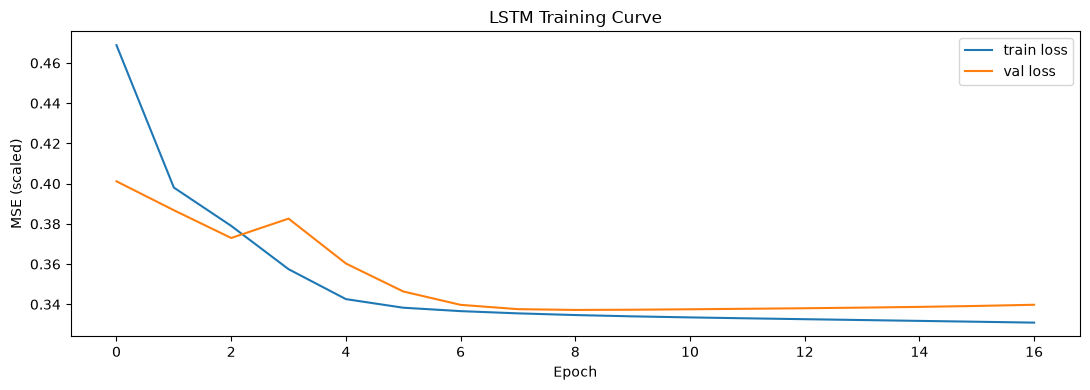

In [23]:
lstm_model = keras.Sequential([
    keras.layers.Input(shape=(LOOKBACK, dl_features.shape[1])),
    keras.layers.LSTM(64),
    keras.layers.Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

early_stop = keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)
history = lstm_model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                          epochs=100, batch_size=32, callbacks=[early_stop], verbose=0)
print(f"Stopped after {len(history.history['loss'])} epochs")

lstm_pred_scaled = lstm_model.predict(X_dl_test, verbose=0).flatten()
lstm_pred = dl_scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()
y_dl_test_orig = dl_scaler.inverse_transform(y_dl_test.reshape(-1, 1)).flatten()

evaluate("LSTM", y_dl_test_orig, lstm_pred)

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title("LSTM Training Curve"); plt.xlabel("Epoch"); plt.ylabel("MSE (scaled)")
plt.legend(); plt.tight_layout(); plt.show()


### GRU
---

Same windowed setup as the LSTM, swapping in a GRU layer (fewer gates/parameters than an LSTM, often trains faster with comparable accuracy on small-to-medium series like this one).

In [24]:
gru_model = keras.Sequential([
    keras.layers.Input(shape=(LOOKBACK, dl_features.shape[1])),
    keras.layers.GRU(64),
    keras.layers.Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')

early_stop_gru = keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)
history_gru = gru_model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                             epochs=100, batch_size=32, callbacks=[early_stop_gru], verbose=0)
print(f"Stopped after {len(history_gru.history['loss'])} epochs")

gru_pred_scaled = gru_model.predict(X_dl_test, verbose=0).flatten()
gru_pred = dl_scaler.inverse_transform(gru_pred_scaled.reshape(-1, 1)).flatten()

evaluate("GRU", y_dl_test_orig, gru_pred)


Stopped after 33 epochs
GRU                           RMSE=2.144   MAE=1.693   R2=0.694


### Results Comparison
---

,RMSE,MAE,R2
LSTM,2.140522,1.687557,0.694819
GRU,2.144461,1.692672,0.693695
Blend (LR + XGB),2.148644,1.690437,0.692498
Linear Regression,2.154877,1.699293,0.690712
Ridge Regression,2.154964,1.699347,0.690687
SARIMAX + Fourier (walk-fwd),2.162854,1.713530,0.688418
Random Forest,2.163439,1.697788,0.688249
XGBoost (tuned),2.180682,1.716247,0.683260
Naive (persistence),2.512994,1.973860,0.579369
Seasonal naive (1yr),3.706175,2.925684,0.085108


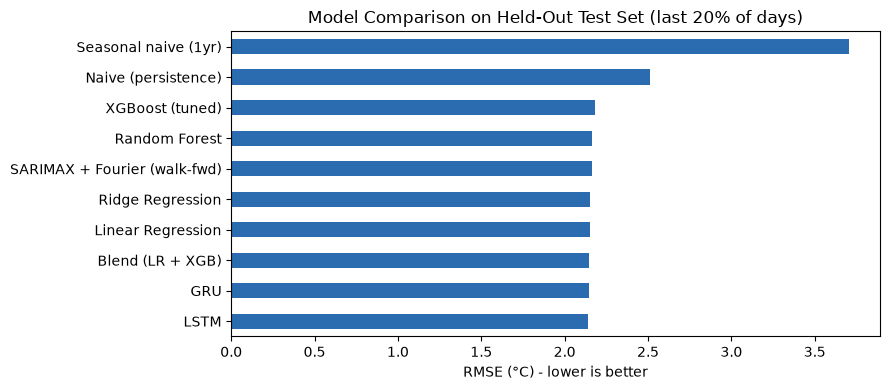

In [25]:
results_df = pd.DataFrame(results).T.sort_values('RMSE')
display(results_df)

fig, ax = plt.subplots(figsize=(9, 4))
results_df['RMSE'].sort_values().plot(kind='barh', color='#2b6cb0', ax=ax)
ax.set_xlabel("RMSE (°C) - lower is better")
ax.set_title("Model Comparison on Held-Out Test Set (last 20% of days)")
plt.tight_layout(); plt.show()


## 11. Best Model - Diagnostics

`RMSE ≈ 2.1-2.2 °C` for essentially every model; ML, SARIMAX, LSTM, GRU alike - is close to the practical noise floor of this problem: with only one weather station's past values as inputs (no humidity, pressure, wind, or satellite data), day-to-day temperature has genuine unpredictable variation that no amount of modeling sophistication removes. All of them comfortably beat both naive baselines, and the fact that a plain linear model matches a recurrent neural network is itself informative, the relationship between lagged temperature, season, and tomorrow's minimum is close to linear once the cyclical calendar features are included, so extra model capacity buys nothing further here.

Best model on test RMSE: LSTM  (RMSE=2.141)


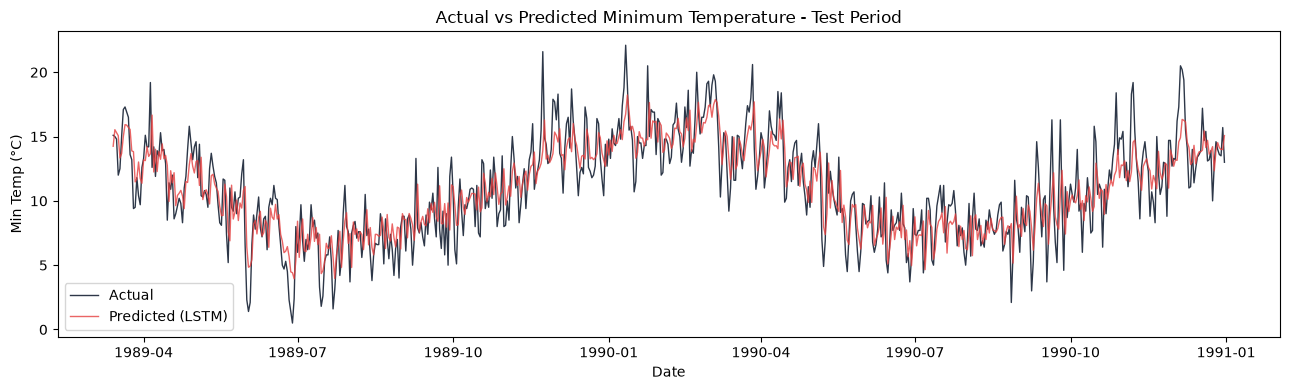

In [26]:
# Pick whichever model actually has the lowest test RMSE, across ALL model
# families (ML, SARIMA, LSTM, GRU) -- rather than assuming the blend wins.
pred_lookup = {
    "Linear Regression": pred_lr,
    "Ridge Regression": pred_ridge,
    "Random Forest": pred_rf,
    "XGBoost (tuned)": pred_xgb,
    "Blend (LR + XGB)": pred_blend,
    "SARIMAX + Fourier (walk-fwd)": sarima_pred,
    "LSTM": lstm_pred,
    "GRU": gru_pred,
}
best_name = results_df['RMSE'].idxmin()
best_pred = pred_lookup[best_name]
print(f"Best model on test RMSE: {best_name}  (RMSE={results_df.loc[best_name, 'RMSE']:.3f})")

test_dates = d['Date'].iloc[split_idx:]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_dates, y_test.values, label='Actual', linewidth=1, color='#2d3748')
ax.plot(test_dates, best_pred, label=f'Predicted ({best_name})', linewidth=1, color='#e53e3e', alpha=0.8)
ax.set_title("Actual vs Predicted Minimum Temperature - Test Period")
ax.set_xlabel("Date"); ax.set_ylabel("Min Temp (°C)")
ax.legend()
plt.tight_layout(); plt.show()


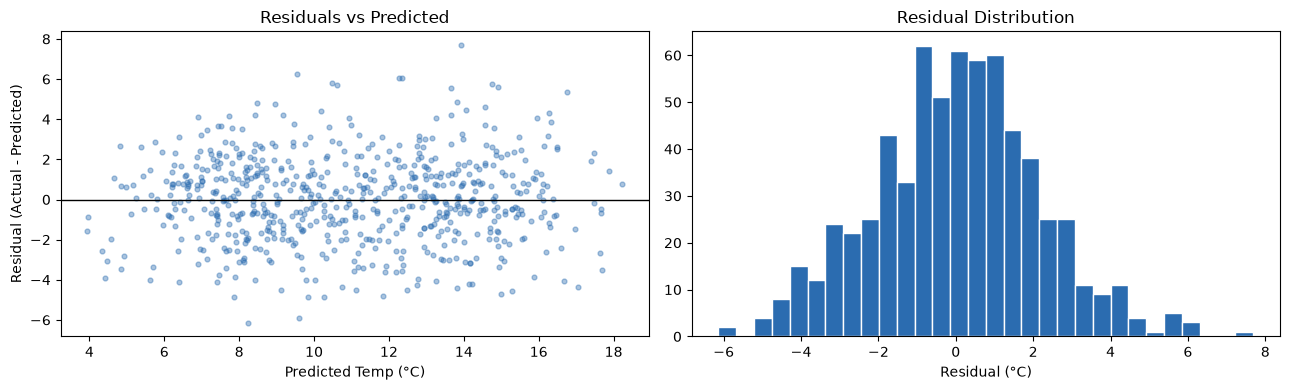

Residual mean: 0.024   Residual std: 2.140


In [27]:
residuals = y_test.values - best_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(best_pred, residuals, alpha=0.4, s=12, color='#2b6cb0')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlabel("Predicted Temp (°C)"); axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=30, color='#2b6cb0', edgecolor='white')
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (°C)")

plt.tight_layout(); plt.show()
print(f"Residual mean: {residuals.mean():.3f}   Residual std: {residuals.std():.3f}")


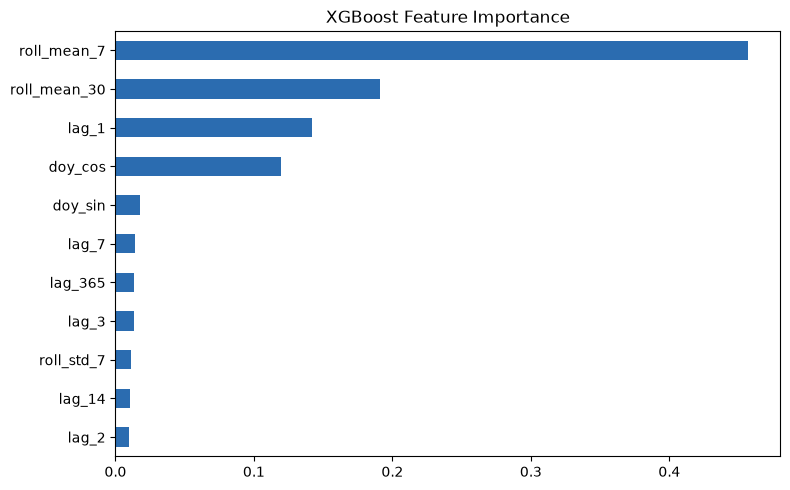

In [28]:
# Feature importance specifically from the XGBoost model (regardless of which
# model won overall) -- useful for understanding *why* the ML approach works,
# even when a different model has the lowest test RMSE.
importances = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', color='#2b6cb0', ax=ax)
ax.set_title("XGBoost Feature Importance")
plt.tight_layout(); plt.show()


## 12. Conclusions 

**Summary**
- Every real model (naive baselines aside) lands in a tight RMSE band of **~2.1-2.2°C**, MAE ~1.7°C, R² ~0.68-0.70, regardless of whether it's a linear model, a tree ensemble, gradient boosting, classical SARIMAX, or a recurrent neural network. That convergence across five very different model families is itself the finding: with only one station's own past minimum temperatures as input, ~2.1°C of day-to-day variation is not predictable from this data, and no amount of extra modeling sophistication buys further improvement.
- The blend of Linear Regression and tuned XGBoost, and the LSTM/GRU, are statistically indistinguishable from each other at this sample size - pick whichever fits your deployment constraints (see below), not whichever number is marginally lowest.
- The walk-forward SARIMAX result is a useful sanity check: it matches the ML models almost exactly once evaluated the *same way* (one day ahead, fed the true previous day's value); but a naive multi-step SARIMA forecast over the full test horizon would have looked meaningfully worse, which is a good illustration of why evaluation protocol matters as much as model choice for time series.




**Streamlit App :**  https://daily-minimum-temperature-forecasting-by-vineeth.streamlit.app/

**GitHub :**    https://github.com/Vineeth-Muraleedharan/Daily-Minimum-Temperature-Forecasting-